In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("data/train.csv")

In [14]:
df

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0
2,1628180742,2,8.0,353733,2,8.0,1142670488,42516,Seizure,3,0,0,0,0,0
3,1628180742,3,18.0,353733,3,18.0,2718991173,42516,Seizure,3,0,0,0,0,0
4,1628180742,4,24.0,353733,4,24.0,3080632009,42516,Seizure,3,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106795,351917269,6,12.0,2147388374,6,12.0,4195677307,10351,LRDA,0,0,0,3,0,0
106796,351917269,7,14.0,2147388374,7,14.0,290896675,10351,LRDA,0,0,0,3,0,0
106797,351917269,8,16.0,2147388374,8,16.0,461435451,10351,LRDA,0,0,0,3,0,0
106798,351917269,9,18.0,2147388374,9,18.0,3786213131,10351,LRDA,0,0,0,3,0,0


## base sanity check

In [ ]:
#check nan
df.isna().sum()
df.describe()
# => no nan and apparently no aberrant data

eeg_id                              0
eeg_sub_id                          0
eeg_label_offset_seconds            0
spectrogram_id                      0
spectrogram_sub_id                  0
spectrogram_label_offset_seconds    0
label_id                            0
patient_id                          0
expert_consensus                    0
seizure_vote                        0
lpd_vote                            0
gpd_vote                            0
lrda_vote                           0
grda_vote                           0
other_vote                          0
dtype: int64

In [ ]:
#check duplicates
df.duplicated().sum()
# => no duplicates

np.int64(0)

## Patients analysis
- how many patients
- how many annotation per patients
- does same patient lead do different ratings

In [ ]:
#number of different patients:
print(f"number of patients: {df["patient_id"].nunique()}")


1950

In [ ]:
#how many annotation per patient
df["patient_id"].value_counts(normalize= True)*100
# => big imbalance between patients.

patient_id
30631    2.073970
2641     2.045880
35627    1.313670
28330    1.275281
54199    1.264045
           ...   
4539     0.000936
41339    0.000936
43246    0.000936
33103    0.000936
38896    0.000936
Name: proportion, Length: 1950, dtype: float64

In [ ]:
#distribution or ratings per patients
df.groupby("patient_id")["expert_consensus"].value_counts().to_csv("./data/rating_per_patient.csv")

In [36]:
df_patients = pd.read_csv("data/rating_per_patient.csv")

In [40]:
df_patients

,patient_id,expert_consensus,count
0,56,Other,60
1,105,Other,38
2,105,GRDA,11
3,105,LPD,5
4,149,GRDA,9
...,...,...,...
3620,65430,Seizure,10
3621,65442,Other,25
3622,65442,Seizure,5
3623,65480,Other,9


In [39]:
df_patients.groupby("patient_id")["count"].sum().sort_values(ascending= False)

patient_id
30631    2215
2641     2185
35627    1403
28330    1362
54199    1350
         ... 
53131       1
24704       1
8278        1
53070       1
16282       1
Name: count, Length: 1950, dtype: int64

In [47]:
def plot_patient_consensus_heatmap(df: pd.DataFrame) -> None:
    # Pivot: patients en lignes, consensus en colonnes, valeurs = count
    pivot = df.pivot_table(index="patient_id", columns="expert_consensus", values="count", aggfunc="sum", fill_value=0)
    # Proportion par patient (normalisation ligne par ligne)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
    # Tri par total de ratings décroissant (plus grosse somme en haut)
    total_counts = pivot.sum(axis=1).sort_values(ascending=True)  # ascending=True car imshow inverse l'axe y
    pivot_pct = pivot_pct.loc[total_counts.index]
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        pivot_pct,
        ax=ax,
        cmap="YlOrRd",
        vmin=0,
        vmax=1,
        linewidths=0,
        cbar_kws={"label": "Proportion (par patient)"},
        annot=len(pivot_pct) <= 50,
        fmt=".0%",
    )
    ax.set_title("Distribution des expert consensus par patient\n(normalisé par patient)", fontsize=14)
    ax.set_xlabel("Expert Consensus")
    ax.set_ylabel("Patient ID")
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()

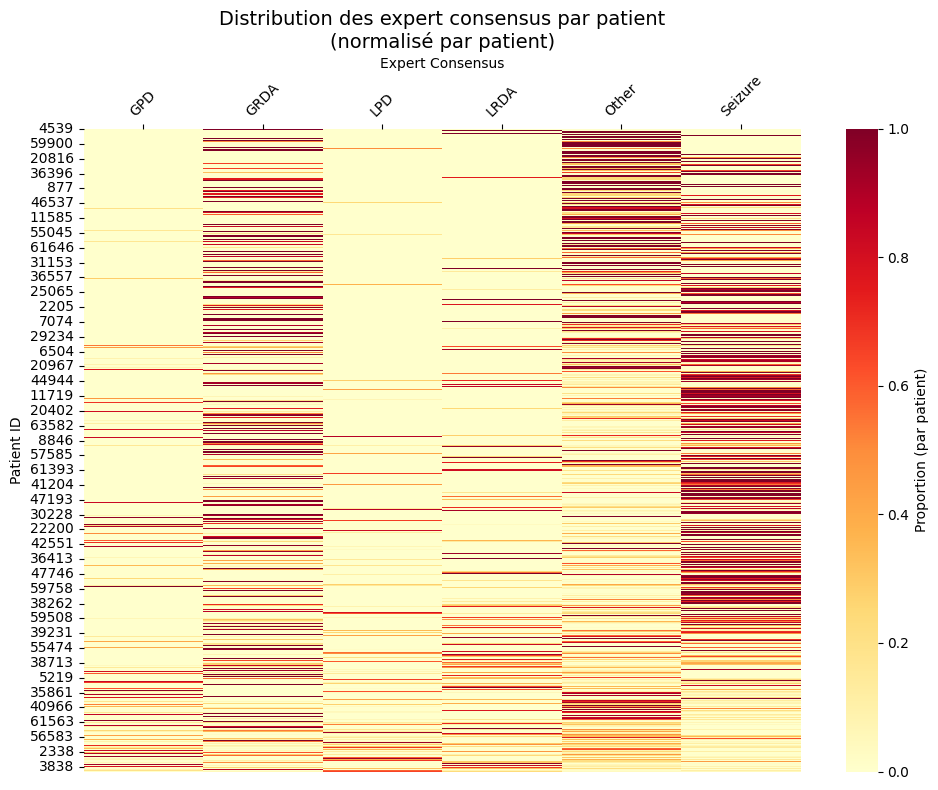

In [48]:
plot_patient_consensus_heatmap(df_patients)

*Conclusion on patients*

- 1950 patients
- big variation of the number of ratings given by patients. 
- same patients have recordings with different ratings (not only "other" vs a clinical rating), but not all patients give "all the ratings". Intuition: distribution of ratings overall different that distribution of ratings within one patient. So selection of patients in a given set may bias the distribution of ratings seen. 


*Actions for project:*
- grouped split to avoid patient leakage
- 